In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [52]:

df = pd.read_csv("data/stud.csv")
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [53]:
# Preparing X & Y  Variables

X = df.drop(columns=['math_score'])
y = df['math_score']

In [54]:
X.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [55]:
y

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math_score, Length: 1000, dtype: int64

In [56]:
# Creating the column transformer 

# Categorical Features 
categorical_features = df.select_dtypes(include=['string']).columns.tolist()
numerical_features = df.select_dtypes(exclude=['string']).columns.tolist()

print(categorical_features)
print(numerical_features)

['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']
['math_score', 'reading_score', 'writing_score']


In [57]:

for category in categorical_features:
    print(f"Category {category}: {df[category].unique()}")    

for category in categorical_features:
    print(f"Category {category}: {df[category].value_counts()}")                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

Category gender: <StringArray>
['female', 'male']
Length: 2, dtype: str
Category race_ethnicity: <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
Category parental_level_of_education: <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
Category lunch: <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
Category test_preparation_course: <StringArray>
['none', 'completed']
Length: 2, dtype: str
Category gender: gender
female    518
male      482
Name: count, dtype: int64
Category race_ethnicity: race_ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64
Category parental_level_of_education: parental_level_of_education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree

In [58]:
num_features = X.select_dtypes(exclude=('string')).columns
cat_features = X.select_dtypes(include=('string')).columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
        ("StandardScaler", numeric_transformer, num_features),
    ]
)


In [59]:
X = preprocessor.fit_transform(X)
X

array([[ 1.        ,  0.        ,  0.        , ...,  1.        ,
         0.19399858,  0.39149181],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         1.42747598,  1.31326868],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.77010859,  1.64247471],
       ...,
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.12547206, -0.20107904],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.60515772,  0.58901542],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.15336989,  1.18158627]], shape=(1000, 19))

In [60]:
X.shape

(1000, 19)

In [61]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((800, 19), (200, 19))

In [66]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error, r2_score

def evaluate_model(true, pred):
    mse = mean_squared_error(true, pred)
    mae = mean_absolute_error(true, pred)
    rmse = root_mean_squared_error(true, pred)
    r2 = r2_score(true, pred)
    return mse, mae,rmse,r2

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

models = {
    "Linear Regression" : LinearRegression(),
    "Lasso Regression" : Lasso(),
    "Ridge Regression" : Ridge(),
    "K-Neighbour Regression" : KNeighborsRegressor(),
    "Descision Tree Regression" : DecisionTreeRegressor(),
    "Random Forest Regression" : RandomForestRegressor(),
    "XGBoost Regressor" : XGBRegressor(),
    "CatBoosting Regressor" : CatBoostRegressor(),
    "Adaboost Regressor" : AdaBoostRegressor(),
}

model_list = []
r2_list = []
rmse_list = []

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train,y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    model_train_mse, model_train_mae, model_train_rmse, model_train_r2_score = evaluate_model(y_train, y_train_pred)
    model_test_mse, model_test_mae, model_test_rmse, model_test_r2_score = evaluate_model(y_test, y_test_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print("#" * 45)
    print('Model performance for training set')
    print(f'- Mean Absolute Error : {model_train_mae:.4f}\n- Mean Squared Error : {model_train_mse:.4f}\n- Mean Root Squared Error : {model_train_rmse:.4f}\n- R2 Score : {model_train_r2_score:.4f}\n')
    print("-"*20)
    print('Model performance for test set')
    print(f'- Mean Absolute Error : {model_test_mae:.4f}\n- Mean Squared Error : {model_test_mse:.4f}\n- Mean Root Squared Error : {model_test_rmse:.4f}\n- R2 Score : {model_test_r2_score:.4f}\n')
    r2_list.append(model_test_r2_score)
    rmse_list.append(model_test_rmse)

    print("=" * 35)
    print("\n")

Linear Regression
#############################################
Model performance for training set
- Mean Absolute Error : 4.2667
- Mean Squared Error : 28.3349
- Mean Root Squared Error : 5.3231
- R2 Score : 0.8743

--------------------
Model performance for test set
- Mean Absolute Error : 4.2148
- Mean Squared Error : 29.0952
- Mean Root Squared Error : 5.3940
- R2 Score : 0.8804



Lasso Regression
#############################################
Model performance for training set
- Mean Absolute Error : 5.2063
- Mean Squared Error : 43.4784
- Mean Root Squared Error : 6.5938
- R2 Score : 0.8071

--------------------
Model performance for test set
- Mean Absolute Error : 5.1579
- Mean Squared Error : 42.5064
- Mean Root Squared Error : 6.5197
- R2 Score : 0.8253



Ridge Regression
#############################################
Model performance for training set
- Mean Absolute Error : 4.2650
- Mean Squared Error : 28.3378
- Mean Root Squared Error : 5.3233
- R2 Score : 0.8743

-------

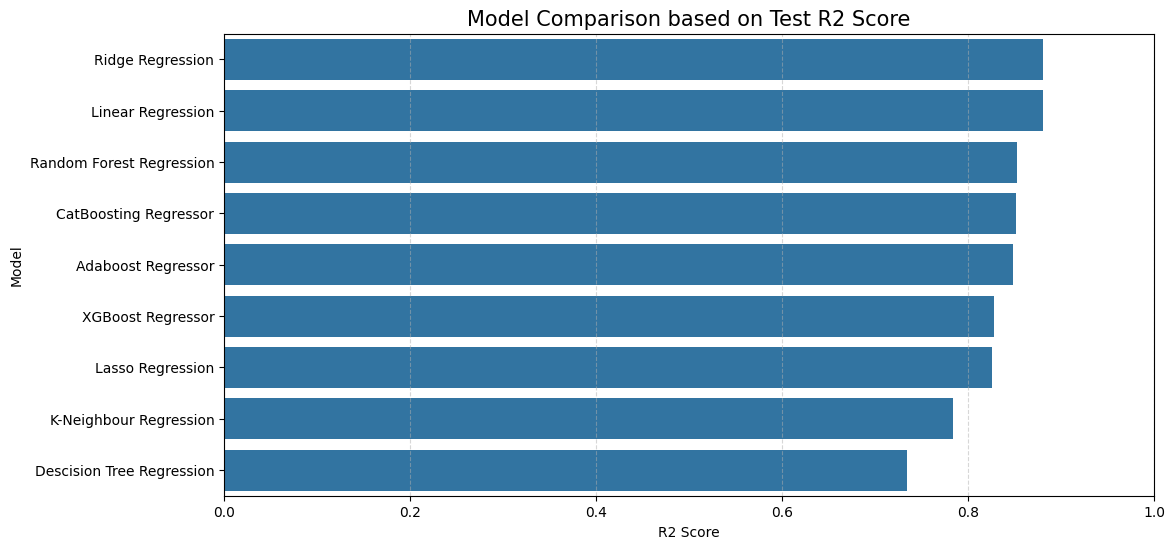

In [67]:
# Create dataframe
results_df = pd.DataFrame({
    "Model": model_list,
    "R2 Score": r2_list
})

# Sort by R2 score (optional but smart)
results_df = results_df.sort_values(by="R2 Score", ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x="R2 Score", y="Model", data=results_df)

plt.title("Model Comparison based on Test R2 Score", fontsize=15)
plt.xlabel("R2 Score")
plt.ylabel("Model")
plt.xlim(0, 1)  # Since R2 typically ranges 0-1
plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.show()

In [71]:
pd.DataFrame(list(zip(model_list,r2_list)), columns=['Model Name', 'R2_Score']).sort_values(by=['R2_Score'], ascending=False)

,Model Name,R2_Score
2,Ridge Regression,0.880593
0,Linear Regression,0.880433
5,Random Forest Regression,0.852726
7,CatBoosting Regressor,0.851632
8,Adaboost Regressor,0.848601
6,XGBoost Regressor,0.827797
1,Lasso Regression,0.825320
3,K-Neighbour Regression,0.783813
4,Descision Tree Regression,0.734752
